In [22]:
import pandas as pd
from pathlib import Path

file_path = Path.home() / "Downloads" / "dec 2024 data.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

       Date Carrier  Airline Name  Flight_Num Origin Dest  Dep_Time  \
0  12/31/24      9E  Endeavor Air        4780    ATL  TUL       820   
1  12/31/24      9E  Endeavor Air        4780    TUL  ATL      1018   
2  12/31/24      9E  Endeavor Air        4781    ATL  MDT      1110   
3  12/31/24      9E  Endeavor Air        4781    MDT  ATL      1350   
4  12/31/24      9E  Endeavor Air        4783    MDT  ATL       600   

   Actual_Dep  Delay  Cancelled  
0       819.0   -1.0          0  
1      1021.0    3.0          0  
2      1106.0   -4.0          0  
3      1342.0   -8.0          0  
4       607.0    7.0          0  
Index(['Date', 'Carrier', 'Airline Name', 'Flight_Num', 'Origin', 'Dest',
       'Dep_Time', 'Actual_Dep', 'Delay', 'Cancelled'],
      dtype='object')


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631944 entries, 0 to 631943
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          631944 non-null  object 
 1   Carrier       631944 non-null  object 
 2   Airline Name  631944 non-null  object 
 3   Flight_Num    631944 non-null  int64  
 4   Origin        631944 non-null  object 
 5   Dest          631944 non-null  object 
 6   Dep_Time      631944 non-null  int64  
 7   Actual_Dep    627666 non-null  float64
 8   Delay         627635 non-null  float64
 9   Cancelled     631944 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 48.2+ MB


In [24]:
df = df[df['Cancelled'] == 0]

df['Cancelled'].value_counts()

0    627365
Name: Cancelled, dtype: int64

In [25]:
df['Delayed'] = (df['Delay'] > 1).astype(int)

df[['Delay', 'Delayed']].head()

,Delay,Delayed
0,-1.0,0
1,3.0,1
2,-4.0,0
3,-8.0,0
4,7.0,1


In [26]:
y = df['Delayed']

X = df.drop(['Delayed', 'Delay'], axis=1)

In [27]:
X = X.drop(['Actual_Dep', 'Flight_Num', 'Airline Name'], axis=1)

In [28]:
df['Date'] = pd.to_datetime(df['Date'])

X['Month'] = df['Date'].dt.month
X['DayOfWeek'] = df['Date'].dt.dayofweek

X = X.drop('Date', axis=1)


In [29]:
X = pd.get_dummies(X, drop_first=True)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6582930192152894
              precision    recall  f1-score   support

           0       0.66      0.94      0.78     79222
           1       0.64      0.17      0.27     46251

    accuracy                           0.66    125473
   macro avg       0.65      0.56      0.52    125473
weighted avg       0.65      0.66      0.59    125473



In [33]:
import pandas as pd

importance = pd.Series(gb_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

print(top_features)


Dep_Time      0.472780
Carrier_WN    0.158455
DayOfWeek     0.138342
Carrier_YX    0.036261
Carrier_OO    0.023069
Carrier_B6    0.021581
Carrier_AA    0.016352
Origin_DFW    0.009581
Carrier_MQ    0.006901
Carrier_AS    0.005732
dtype: float64


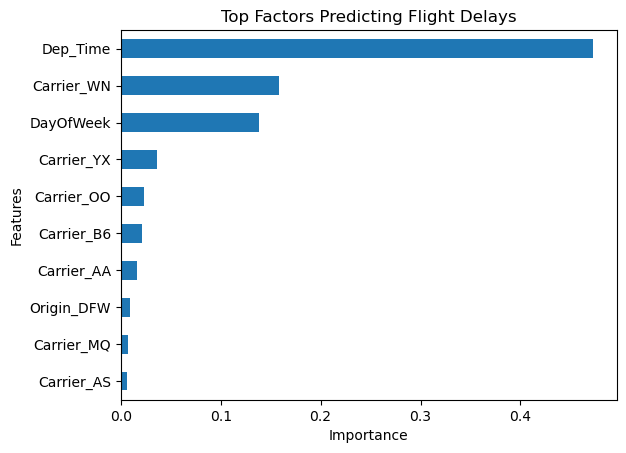

In [34]:
import matplotlib.pyplot as plt

top_features = importance.sort_values(ascending=True).tail(10)

plt.figure()
top_features.plot(kind='barh')

plt.title("Top Factors Predicting Flight Delays")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()


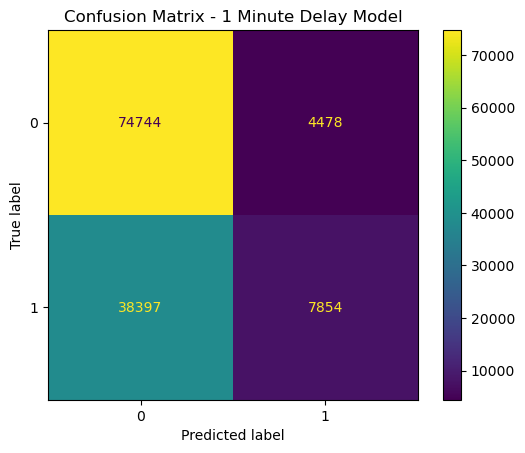

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

import matplotlib.pyplot as plt
plt.title("Confusion Matrix - 1 Minute Delay Model")
plt.show()